## Analyis of Algorithm

In [5]:
library(terra)
library(sf)
library(dplyr)
library(lwgeom)
library(tidyverse)
library(tictoc)
library(tmap)
#library(fasterize)
library(raster)
library(exactextractr)

In [6]:
terraOptions(memfrac = 0.6)

In [7]:
getwd()

[1] "/home/etienne/Desktop/repos/Github_Enterprise/BSc_project/code"

### 1. Load in the data

In [8]:

r <- terra::rast("../data/thermal_rasters_FINAL/mean_v01emme.tif")

line <- sf::st_read("../data/Centerlines_FINAL/Emme_V01.shp", quiet = TRUE) |> sf::st_zm(TRUE, "ZM")


In [9]:
ext_full <- terra::ext(r)
y_cutoff <- ext_full$ymin + (ext_full$ymax - ext_full$ymin) * (1/3)
ext_top <- terra::ext(ext_full$xmin, ext_full$xmax, y_cutoff, ext_full$ymax)

r    <- terra::crop(r, ext_top)
line <- sf::st_crop(line, ext_top)

Warning message:
attribute variables are assumed to be spatially constant throughout all geometries 


In [10]:
stopifnot(terra::nlyr(r) == 1) # if not only one layer
names(r) <- "T"
if (terra::is.lonlat(r)) stop("Raster must be in a metric CRS.")


In [11]:
rres   <- terra::res(r)
cell_m <- mean(rres)



In [12]:
  if (!is.na(sf::st_crs(line)) &&
      !identical(terra::crs(r), sf::st_crs(line)$wkt)) {
    line <- sf::st_transform(line, terra::crs(r))

}

# This specific object has only one line, somehtimes there are multible ->  then
# we need to do a join.
line

Simple feature collection with 1 feature and 2 fields
Geometry type: LINESTRING
Dimension:     XY
Bounding box:  xmin: 2607224 ymin: 1212140 xmax: 2614673 ymax: 1226331
Projected CRS: CH1903+ / LV95
  NAME   Length                       geometry
1 Emme 30165.01 LINESTRING (2614673 1212140...

In [13]:
g <- sf::st_union(line)

Dont realy know why this is. It seems to me like this is necessairy because not all data is the same -> Better leave it in

---
### Parameters of the Function

In [14]:
step_m            = 500       # slab length along centerline (m)
buffer_px         = 3         # corridor half-width for reference T (pixels)
delta_C           = 1.0       # temperature anomaly threshold (deg C)
min_patch_area_m2 = 2         # drop patches smaller than this
round_to          = 0.1       # round temperatures to this precision
slab_halfwidth_m  = 60        # lateral half-width of slab polygons (m)
connect_diagonals = TRUE      # 8-connectivity when dissolving patches
union_chunk_size  = 50000L    # max cells per dissolve chunk
epsilon = 0.01

In [15]:
  if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
    g <- sf::st_collection_extract(g, "LINESTRING")
  if (inherits(g, "sfc_MULTILINESTRING")) {
    g <- sf::st_line_merge(g)
    if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
      g <- sf::st_collection_extract(g, "LINESTRING")
  }

In [16]:
  if (!inherits(g, "sfc_LINESTRING"))
    stop("Centerline must resolve to a LINESTRING.")
  line <- sf::st_sf(geometry = g)


In [17]:
rfactor <- if (!is.null(round_to) && round_to > 0) 1 / round_to else NA_real_

rfactor

[1] 10

In [18]:
toc()


**Timing**

This first set of steps is very fast. That was to be exected. terra only holds a pointer to the data in memory. Only upon evaluation, data is actually read. sf I am not quite shure. But it is also reasonable, that loading a single line into memory is not computationally expensive. So all the checks of coordinate reference systems etc.

---
### 2. Building slabs

In [19]:
L <- as.numeric(sf::st_length(line))
S <- step_m

# I am quite shure this has its good reasons why it is how it is.
# if seq yields NULL or something, then you still got a vector with a 0
pos <- sort(unique(c(0, seq(0,1, by = S/ L), 1)))

# number of positions ?
npt <- length(pos)

# this returns a warning, if we e.g. want to do step size 5000m but
# the river segment is not even 5000 m long
if (npt < 2) stop("Too few stations for step = ", S)

# these are simple difference vectors 
from <- pos[1:(npt - 1)]
to   <- pos[2:npt]

k    <- length(from)

# not quite shure, why this is needed. This gets the
# geometry from the sf object which is a dataframe with a column holding the
# geometries
g1   <- sf::st_geometry(line)[1]


# this returns a list filled with NULL
subs_list <- vector("list", k)


# from and to are both arrays
for (j in seq_len(k)) {
  subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
}

# ?do.call
# ok I see. do.call is like a map. It applies
# the function c() to every element of the subs list
subs <- do.call(c,subs_list)


subs %>% class()

# Ok and additionally it seems, like the objects
# inside subs_list interact with c() in a way that they
# get lumped together to a larger geometry object
# so this is a way of "gluing" the segments together to a single object

# ok now I understand what slabs are.
# these are polygons that got greated from
# a linestring (segments) via e buffer.
# the end of the buffer is flatt, to this
# sort of creates rectanlge
# 
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)



In [20]:
# these are simple difference vectors 
from <- pos[1:(npt - 1)]
to   <- pos[2:npt]

k    <- length(from)

# not quite shure, why this is needed. This gets the
# geometry from the sf object which is a dataframe with a column holding the
# geometries
g1   <- sf::st_geometry(line)[1]

g1

Geometry set for 1 feature 
Geometry type: LINESTRING
Dimension:     XY
Bounding box:  xmin: 2607224 ymin: 1212140 xmax: 2614673 ymax: 1226331
Projected CRS: CH1903+ / LV95
LINESTRING (2614673 1212140, 2614672 1212145, 2...

In [21]:
# this returns a list filled with NULL
subs_list <- vector("list", k)

subs_list %>% head()

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

[[5]]
NULL

[[6]]
NULL


In [22]:
# from and to are both arrays
for (j in seq_len(k)) {
  subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
}

# ?do.call
# ok I see. do.call is like a map. It applies
# the function c() to every element of the subs list
subs <- do.call(c,subs_list)


subs %>% class()

# Ok and additionally it seems, like the objects
# inside subs_list interact with c() in a way that they
# get lumped together to a larger geometry object
# so this is a way of "gluing" the segments together to a single object

# ok now I understand what slabs are.
# these are polygons that got greated from
# a linestring (segments) via e buffer.
# the end of the buffer is flatt, to this
# sort of creates rectanlge
# 
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)



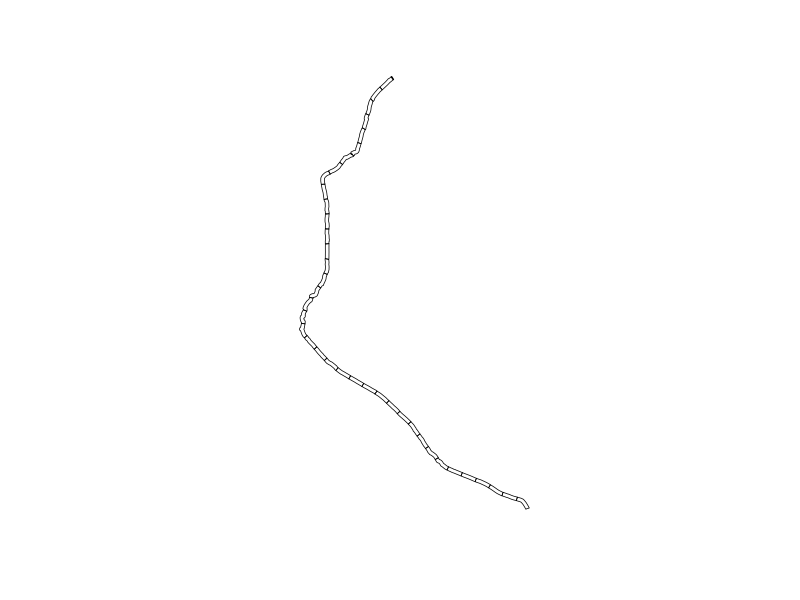

In [23]:
slabs_sf %>% plot()

These are nsome nice slaps ngl

In [24]:
toc()

In [25]:
?st_buffer

**Timing**

This slap building steps also seems to be rather fast. No wonder, as the geodata in play here is very light weight and the rest are just native R functions. (So far this is great but Im rather certain, that the whole number crunching is up ahead)

---
### 3. Extract slab pixels

In [26]:
slabs_terra <- terra::vect(slabs_sf)

In [27]:
# terra::extract(r, slabs_terra, cells = TRUE)

This seems to be very very memory intensive. (It is, since this basically creates a dataframe that holds a row for every pixel.) Idk, this is maybe a super fast way of doing this whole reference temperature calculations if one has enough memory (I don't). But on the HPC i have plenty of memory.

I guess I will still try to find an alternative way of doing this here. Ofc, the computations over the resulting dataframe can be parallelized (because some of these reference temperature calculations are embarissingly parallel + every slab on its own is parallel too). But I can also parallelize this in terra (hopefully). I think I could build the buffer means using

rasterisation of thinner slaps -> zonal operation with the thiner slap raster. And then I could do reclassification of the big slaps using the means of the smaller slaps (median buffers) as burn in. Then all that would be left is some raster algebra.

The neat part is, that this is all powered by GDAL (like almost everything ofc.). So on the hpc i can just try to krank up the number of threads used by gdal and potentially allready get a decent speedup without even changing that much about the code.

In [28]:
buffer_m <- cell_m *  buffer_px

slabs_buffer <- sf::st_buffer(subs,
                          dist        = buffer_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)


slabs_buffer_sf <- sf::st_sf(geometry = slabs_buffer) %>%
  mutate(slap_id = row_number())


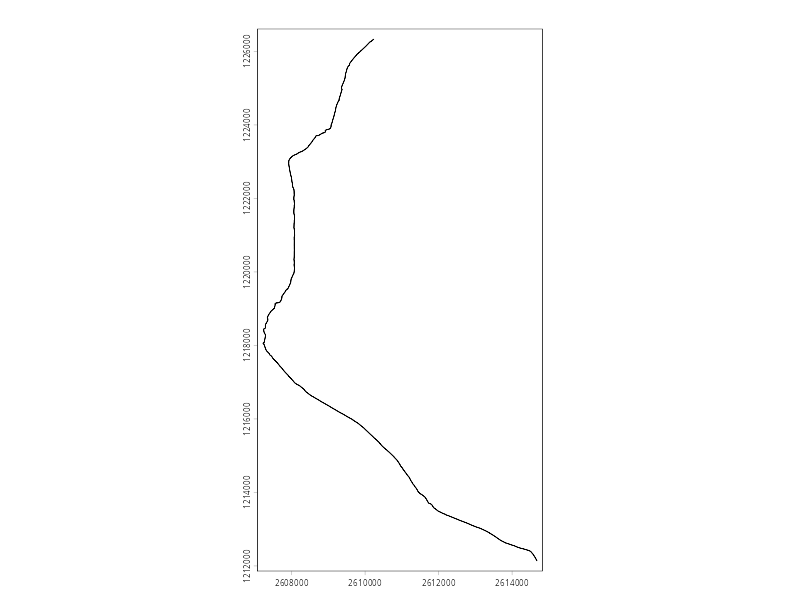

In [29]:
slaps_buffer_vect <-slabs_buffer_sf %>%
terra::vect()


slaps_buffer_vect %>% plot()

In [30]:
tictoc::tic()
zone_r <- terra::rasterize(slaps_buffer_vect, r, field = "slap_id")
tictoc::toc()

140.298 sec elapsed                       ======================================


In [32]:
getwd()

[1] "/home/etienne/Desktop/repos/Github_Enterprise/BSc_project/code"

In [ ]:
sf::write_sf(slabs_buffer_sf,"../data/test_dir/slabs_buffer_sf.shp")

 

In [26]:
# The full raster is ~64k x ~103k pixels at 0.207m resolution.
# At that scale, 6-pixel-wide buffer slabs appear as sub-pixel dots.
# Zoom into the first few slabs to verify they are real polygons:
ext_zoom <- terra::ext(slaps_buffer_vect[1:5, ])
terra::plot(terra::crop(zone_r, ext_zoom))
#terra::plot(slaps_buffer_vect[1:5, ], add = TRUE, border = "red")

: [1m[33mError[39m in `h()`:[22m
[33m![39m error in evaluating the argument 'x' in selecting a method for function 'plot': error in evaluating the argument 'x' in selecting a method for function 'crop': object 'zone_r' not found

In [ ]:
mean_raster <- terra::zonal(r, zone_r,fun = "mean", na.rm = TRUE)


In [67]:
writeLines(
  paste0(
    paste0("[", mean_raster$slap_id, ",", mean_raster$slap_id, "]=", mean_raster$T, collapse = "; "),
    "; DEFAULT=NO_DATA"
  ),
  "../data/test_dir/median_lookup_gdal.txt"
)

In [42]:
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)


slabs_raster <- terra::rast()

In [50]:
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)


slabs_sf <- sf::st_sf(geometry = slabs) %>%
  mutate(slap_id = row_number()) 


slaps_sf_vect <- slabs_sf %>%
  mutate(slap_id = row_number()) %>%
  terra::vect()




#### Rasterize zusing terra vs rasterize using GDAL

In [45]:
tic()
zone_r_big <- terra::rasterize(slaps_sf_vect, r, field = "slap_id")
toc()

138.62 sec elapsed                        ======================================


In [ ]:
tic()
sf::write_sf(slabs_sf,"../data/test_dir/slabs_sf.shp")

system(
"gdal vector rasterize -i ../data/test_dir/slabs_sf.shp -o ../data/test_dir/zone_r_big.tif -a slap_id --resolution 0.20728,0.20728 --overwrite --extent 2607201,1212140,2620465,1226340"
)

zone_r_big <- terra::rast("../data/test_dir/zone_r_big.tif")
toc()

0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:19.
21.186 sec elapsed


This is just so much faster that it is almost puzzeling to me. Lets see wheter this will hold up on the HPC.

In [69]:
e <- terra::ext(r)
cat(e$xmin, e$ymin, e$xmax, e$ymax)
# also get dimensions
cat(terra::nrow(r), terra::ncol(r))

2607201 1212140 2620465 122634068510 63993

In [ ]:
Tmean <- terra::classify(zone_r_big,mean_raster)


In [ ]:
r %>% ext()

SpatExtent : 2607200.88077964, 2620465.349803, 1212139.65001185, 1226340.40281 (xmin, xmax, ymin, ymax)

In [85]:
Tmean %>% ext()

SpatExtent : 2607162.20751267, 2614730.82943267, 1212116.46335201, 1226381.26567201 (xmin, xmax, ymin, ymax)

In [80]:
toc()

64.001 sec elapsed


In [ ]:
tic()
terra::writeRaster(Tmean, "../data/test_dir/Tmean.tif", overwrite = TRUE)
terra::writeRaster(r,"../data/test_dir/r.tif", overwrite = TRUE)
system(
  'gdal raster calc -i "A=../data/test_dir/r.tif" -i "B=../data/test_dir/Tmean.tif" --calc "((A - B) <= -0.07) ? (A - B) : NaN" --no-check-extent -o ../data/test_dir/binary_out.tif --overwrite
)

toc()

ERROR 1: calc: Positional arguments starting at 'INPUTS' have not been specified.
Usage: gdal raster calc [OPTIONS] <INPUTS>... <OUTPUT>
Try 'gdal raster calc --help' for help.
sh: 2: -i: not found
sh: 3: -i: not found
sh: 4: --calc: not found
sh: 5: --no-check-extent: not found
sh: 6: -o: not found
Warning message:
In system("gdal raster calc \n  -i \"A=../data/test_dir/r.tif\" \n  -i \"B=../data/test_dir/Tmean.tif\" \n  --calc \"((A - B) <= -0.07) ? (A - B) : NaN\" \n  --no-check-extent \n  -o ../data/test_dir/binary_out.tif --overwrite\n") :
  error in running command


158.553 sec elapsed


In [83]:
system(
  'gdal raster calc -i "A=../data/test_dir/r.tif" -i "B=../data/test_dir/Tmean.tif" --calc "((A - B) <= -0.07) ? (A - B) : NaN" --no-check-extent -o ../data/test_dir/binary_out.tif --overwrite'
)

ERROR 1: Inputs do not have the same dimensions.


In [86]:
tic()
flagged_pixels <- r - Tmean
binary <- flagged_pixels <= (-1* delta_C)
binary[binary==0] <- NA
toc()

: [1m[33mError[39m:[22m
[33m![39m [-] extents do not match

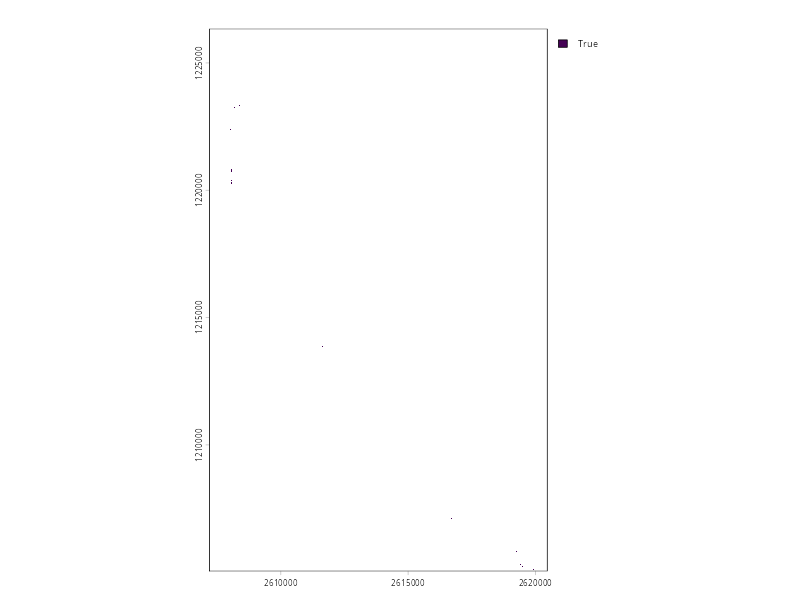

In [ ]:
binary %>% plot()

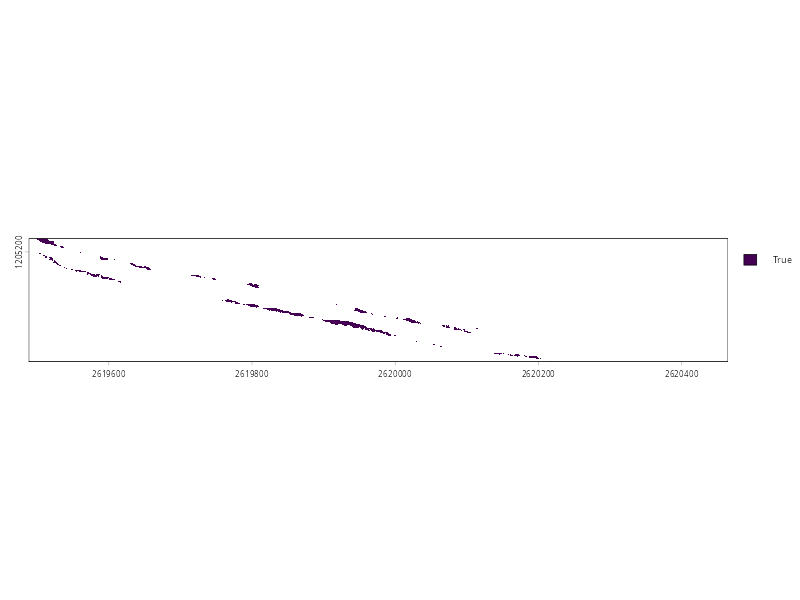

In [ ]:
ext_zoom <- terra::ext(slaps_buffer_vect[1:2, ])
terra::plot(terra::crop(binary, ext_zoom))

In [ ]:
patches_v <- terra::as.polygons(binary,
                                dissolve = TRUE,
                                eight    = FALSE)

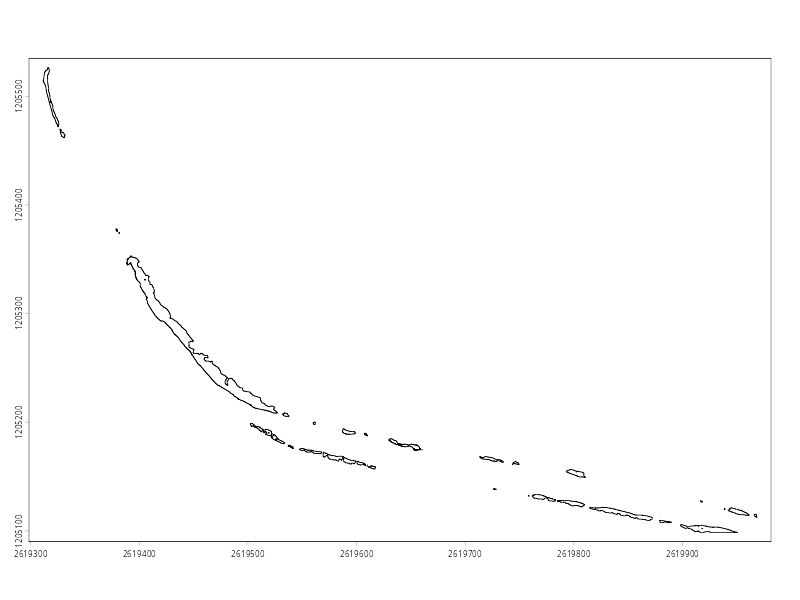

In [ ]:
ext_zoom <- terra::ext(slaps_buffer_vect[2:3, ])
terra::plot(terra::crop(patches_v, ext_zoom))

In [ ]:
eps <- if (connect_diagonals) cell_m  * 0.1 else 0

patches_sf <- patches_v %>%
  sf::st_as_sf() %>%
  sf::st_cast("POLYGON") %>% 
  sf::st_buffer(eps) %>%
  sf::st_union() %>%
  sf::st_buffer(-eps) %>%
  sf::st_as_sf() %>%
  sf::st_cast("POLYGON")


Warning message:
In st_cast.sf(., "POLYGON") :
  repeating attributes for all sub-geometries for which they may not be constant


A connectivity of eight is no longer needed since this logic is allready a side effect of the morphological closing.

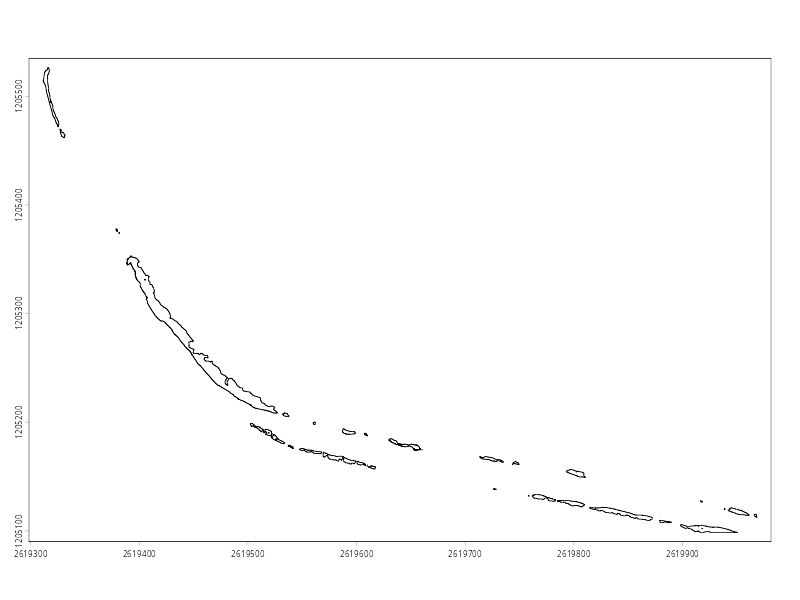

In [ ]:
ext_zoom <- terra::ext(slaps_buffer_vect[2:3, ])
terra::plot(terra::crop(patches_v, ext_zoom))

In [ ]:
patches_large <- patches_sf %>%
  filter(as.numeric(st_area(.)) >= 2) %>%
  mutate(ID = row_number())


patches_large

Simple feature collection with 114 features and 1 field
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 2607201 ymin: 1205050 xmax: 2620203 ymax: 1225804
Projected CRS: CH1903+ / LV95
First 10 features:
                                x ID
1  POLYGON ((2620187 1205054, ...  1
2  POLYGON ((2620181 1205055, ...  2
3  POLYGON ((2620136 1205058, ...  3
4  POLYGON ((2620131 1205059, ...  4
5  POLYGON ((2620112 1205093, ...  5
6  POLYGON ((2620082 1205093, ...  6
7  POLYGON ((2620066 1205097, ...  7
8  POLYGON ((2620053 1205071, ...  8
9  POLYGON ((2620011 1205105, ...  9
10 POLYGON ((2620001 1205106, ... 10

In [ ]:
stats_per_poly <- terra::extract(r,patches_large) %>%
  group_by(ID) %>%
  summarise(
    mean_temp = mean(T),
    min_temp = min(T),
    max_temp = max(T),
    median_temp = median(T)
  )

stats_per_poly

# A tibble: 114 × 5
      ID mean_temp min_temp max_temp median_temp
   <dbl>     <dbl>    <dbl>    <dbl>       <dbl>
 1     1      16.4     12.5     18.9        16.3
 2     2      18.8     18.6     18.9        18.8
 3     3      18.4     13.2     18.9        18.5
 4     4      18.8     18.6     18.9        18.8
 5     5      18.4     16.5     18.9        18.6
 6     6      18.9     18.6     18.9        18.9
 7     7      18.8     18.3     18.9        18.8
 8     8      18.2     16.8     18.9        18.4
 9     9      17.7     14.8     18.9        18.0
10    10      17.8     16.1     18.9        18.0
# ℹ 104 more rows
# ℹ Use `print(n = ...)` to see more rows

In [ ]:
patches_large_with_stas <- patches_large  %>%
  left_join(stats_per_poly, by = "ID")

patches_large_with_stas

Simple feature collection with 114 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 2607201 ymin: 1205050 xmax: 2620203 ymax: 1225804
Projected CRS: CH1903+ / LV95
First 10 features:
   ID mean_temp min_temp max_temp median_temp                              x
1   1  16.35246 12.50058 18.90126    16.29272 POLYGON ((2620187 1205054, ...
2   2  18.77176 18.55838 18.90053    18.78479 POLYGON ((2620181 1205055, ...
3   3  18.37576 13.16896 18.90145    18.54168 POLYGON ((2620136 1205058, ...
4   4  18.76501 18.61846 18.89324    18.76819 POLYGON ((2620131 1205059, ...
5   5  18.37560 16.52761 18.89845    18.61165 POLYGON ((2620112 1205093, ...
6   6  18.86860 18.64187 18.90191    18.87646 POLYGON ((2620082 1205093, ...
7   7  18.78872 18.28078 18.90149    18.82767 POLYGON ((2620066 1205097, ...
8   8  18.24647 16.83179 18.88303    18.40764 POLYGON ((2620053 1205071, ...
9   9  17.68684 14.80035 18.90055    17.99842 POLYGON ((2620011 1205105, ...
10 10  17.80

In [ ]:
patches_large_with_stas %>% colnames()

[1] "ID"          "mean_temp"   "min_temp"    "max_temp"    "median_temp" "geometry"   

In [ ]:
slab_means <- exact_extract(Tmean, patches_large_with_stas, fun ="mean" ) %>%
  rename(slab_mean_T = slap_id)

Cannot preload entire working area of 6280641000 cells with max_cells_in_memory = 3e+07. Raster values will be read for each feature individually.
  |============================================================================================================================================================================================| 100%


In [ ]:
exact_extract(Tmean, patches_large_with_stas, fun ="mean" )

Cannot preload entire working area of 6280641000 cells with max_cells_in_memory = 3e+07. Raster values will be read for each feature individually.
  |============================================================================================================================================================================================| 100%


  [1] 19.90193 19.90193 19.90192 19.90193 19.90193 19.90193 19.90193 19.90193 19.90193 19.90193 19.90193 19.79596 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895
 [22] 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.76895 19.57115 19.76895 19.76895 19.76895 19.53446 19.53446 19.53445 19.59621 19.59621
 [43] 19.59621 19.64799 19.92486 19.93989 19.93989 19.93989 20.08337 20.08337 20.08337 20.08337 20.08337 20.16969 20.16969 20.16969 20.16969 20.16969 20.16969 20.16969 20.16969 20.19587 20.19587
 [64] 20.19587 20.19587 19.62219 21.29833 21.29833 21.29833 21.29833 21.83503 21.83502 21.83503 20.93082 20.93082 20.93082 20.93082 20.93082 20.93082 20.93082 20.59040 20.62355 20.62355 18.22008
 [85] 19.22156 18.01786 18.01786 22.45108 19.50879 19.50879 22.75718 22.75718 22.75718 22.75718 22.75718 21.33280 21.33280 21.33280 21.51685 21.51685 22.33624 22.33624 22.33624 22.33624 22.33624
[106] 22.33624 22.33624 2

In [ ]:
patches_large_with_stas <- patches_large  %>%
  left_join(stats_per_poly, by = "ID")

final_patches <- patches_large_with_stas %>%
  left_join(slab_means, by = "ID") %>%
  mutate(deltaT = slab_mean_T - mean_temp) %>%
  filter(deltaT >= delta_C)


final_patches

Simple feature collection with 114 features and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 2607201 ymin: 1205050 xmax: 2620203 ymax: 1225804
Projected CRS: CH1903+ / LV95
First 10 features:
   ID mean_temp min_temp max_temp median_temp slab_mean_T                              x   deltaT
1   1  16.35246 12.50058 18.90126    16.29272    19.90193 POLYGON ((2620187 1205054, ... 3.549465
2   2  18.77176 18.55838 18.90053    18.78479    19.90193 POLYGON ((2620181 1205055, ... 1.130168
3   3  18.37576 13.16896 18.90145    18.54168    19.90193 POLYGON ((2620136 1205058, ... 1.526170
4   4  18.76501 18.61846 18.89324    18.76819    19.90193 POLYGON ((2620131 1205059, ... 1.136912
5   5  18.37560 16.52761 18.89845    18.61165    19.90193 POLYGON ((2620112 1205093, ... 1.526329
6   6  18.86860 18.64187 18.90191    18.87646    19.90193 POLYGON ((2620082 1205093, ... 1.033325
7   7  18.78872 18.28078 18.90149    18.82767    19.90193 POLYGON ((2620066 1205097, ... 1.11320

ℹ tmap modes "plot" - "view"
ℹ toggle with ]8;;x-r-run:tmap::ttm()tmap::ttm()]8;;
This message is displayed once per session.


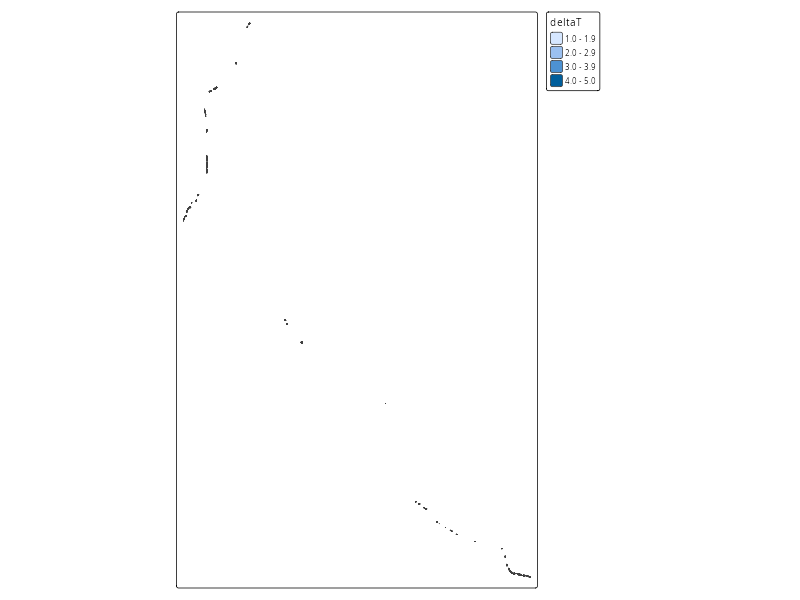

In [ ]:
tmap_mode("plot")

tm_shape(final_patches) +
    tm_polygons(fill = "deltaT")

In [ ]:
detect_cwp_single <- function(
    ras_path,
    line_path,
    step_m            = 500,
    buffer_px         = 3,
    delta_C           = 1.0,
    min_patch_area_m2 = 2,
    round_to          = 0.1,
    slab_halfwidth_m  = 60,
    connect_diagonals = TRUE,
    union_chunk_size  = 50000L
) {

r <- terra::rast(ras_path)
line <- sf::st_read(line_path, quiet = TRUE) |> sf::st_zm(TRUE, "ZM")
  
stopifnot(terra::nlyr(r) == 1)
names(r) <- "T"
if (terra::is.lonlat(r)) stop("Raster must be in a metric CRS.")

rres   <- terra::res(r)
cell_m <- mean(rres)

if (!is.na(sf::st_crs(line)) &&
  !identical(terra::crs(r), sf::st_crs(line)$wkt)) {
  line <- sf::st_transform(line, terra::crs(r))
}

g <- sf::st_union(line)
  
if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
  g <- sf::st_collection_extract(g, "LINESTRING")
if (inherits(g, "sfc_MULTILINESTRING")) {
  g <- sf::st_line_merge(g)
  if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
    g <- sf::st_collection_extract(g, "LINESTRING")
}
  
rfactor <- if (!is.null(round_to) && round_to > 0) 1 / round_to else NA_real_

L <- as.numeric(sf::st_length(line))
S <- step_m

pos <- sort(unique(c(0, seq(0, 1, by = S / L), 1)))
npt <- length(pos)

if (npt < 2) stop("Too few stations for step = ", S)

from <- pos[1:(npt - 1)]
to   <- pos[2:npt]
k    <- length(from)

g1 <- sf::st_geometry(line)[1]

subs_list <- vector("list", k)
for (j in seq_len(k)) {
  subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
}

subs <- do.call(c, subs_list)

slabs <- sf::st_buffer(subs,
                       dist        = slab_halfwidth_m,
                       endCapStyle = "FLAT",
                       joinStyle   = "MITRE",
                       mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)

slabs_terra <- terra::vect(slabs_sf)

buffer_m <- cell_m * buffer_px

slabs_buffer <- sf::st_buffer(subs,
                              dist        = buffer_m,
                              endCapStyle = "FLAT",
                              joinStyle   = "MITRE",
                              mitreLimit  = 2)
slabs_buffer_sf <- sf::st_sf(geometry = slabs_buffer)

slaps_buffer_vect <- slabs_buffer_sf %>%
  mutate(slap_id = row_number()) %>%
  terra::vect()

slabs <- sf::st_buffer(subs,
                       dist        = slab_halfwidth_m,
                       endCapStyle = "FLAT",
                       joinStyle   = "MITRE",
                       mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)

slaps_sf_vect <- slabs_sf %>%
  mutate(slap_id = row_number()) %>%
  terra::vect()

zone_r_big <- terra::rasterize(slaps_sf_vect, r, field = "slap_id")

r_rounded <- round(r * rfactor) / rfactor

zone_r <- terra::rasterize(slaps_buffer_vect, r_rounded, field = "slap_id")

mean_raster <- terra::zonal(r_rounded, zone_r, fun = "median", na.rm = TRUE)

Tmean <- terra::classify(zone_r_big, mean_raster)

flagged_pixels <- r_rounded - Tmean
binary <- flagged_pixels <= (-1 * delta_C)

binary[binary == 0] <- NA
patches_v <- terra::as.polygons(binary, dissolve = TRUE, eight = FALSE)

eps <- if (connect_diagonals) cell_m * 0.1 else 0

patches_sf <- patches_v %>%
  sf::st_as_sf() %>%
  sf::st_cast("POLYGON") %>%
  sf::st_buffer(eps) %>%
  sf::st_union() %>%
  sf::st_buffer(-eps)

patches_large <- patches_sf %>%
  filter(as.numeric(st_area(.)) >= 2) %>%
  mutate(ID = row_number())

stats_per_poly <- terra::extract(r_rounded, patches_large) %>%
  group_by(ID) %>%
  summarise(
    mean_temp   = mean(T),
    min_temp    = min(T),
    max_temp    = max(T),
    median_temp = median(T)
  )

patches_large_with_stas <- patches_large %>%
  left_join(stats_per_poly, by = "ID") %>%
  select(!T)

slab_means <- terra::extract(Tmean, vect(patches_large_with_stas), fun = "mean") %>%
  rename(slab_mean_T = slap_id)

final_patches <- patches_large_with_stas %>%
  left_join(slab_means, by = "ID") %>%
  mutate(deltaT = slab_mean_T - mean_temp) %>%
  filter(deltaT >= delta_C)

return(final_patches)

}

In [ ]:
detect_cwp_single(
  "../data/thermal_rasters_FINAL/mean_v01emme.tif",
"../data/Centerlines_FINAL/Emme_V01.shp"
)

===-------|---------|---------|---------|==============

: [1m[33mError[39m:[22m
[33m![39m [rasterize] interrupted

## The original function

In [ ]:
polygonize_flagged_vector <- function(flagged_cells, r,
                                      chunk_size   = 50000L,
                                      connect_diag = TRUE) {

  if (!length(flagged_cells)) {
    return(sf::st_sf(geometry = sf::st_sfc(), crs = sf::st_crs(terra::crs(r))))
  }

  res    <- terra::res(r)
  crs_wk <- terra::crs(r)

  make_rects_sfc <- function(xc, yc, rx, ry, crs_wk) {
    polys <- vector("list", length(xc))
    for (i in seq_along(xc)) {
      x <- xc[i]; y <- yc[i]
      m <- matrix(c(
        x - rx/2, y - ry/2,
        x + rx/2, y - ry/2,
        x + rx/2, y + ry/2,
        x - rx/2, y + ry/2,
        x - rx/2, y - ry/2
      ), ncol = 2, byrow = TRUE)
      polys[[i]] <- sf::st_polygon(list(m))
    }
    sf::st_sfc(polys, crs = sf::st_crs(crs_wk))
  }

  n      <- length(flagged_cells)
  chunks <- split(seq_len(n), ceiling(seq_len(n) / chunk_size))
  parts_sv <- vector("list", length(chunks))

  for (ci in seq_along(chunks)) {
    idx <- chunks[[ci]]
    xy  <- terra::xyFromCell(r, flagged_cells[idx])
    sfc <- make_rects_sfc(xy[, 1], xy[, 2], res[1], res[2], crs_wk)

    v       <- terra::vect(sf::st_sf(geometry = sfc))
    v$grp   <- 1L
    vd      <- terra::aggregate(v, by = "grp")
    parts_sv[[ci]] <- vd
  }

  parts_sf <- lapply(parts_sv, sf::st_as_sf)
  stitched <- do.call(rbind, parts_sf)
  geom     <- sf::st_geometry(stitched)
  geom     <- try(sf::st_make_valid(geom), silent = TRUE)

  eps <- if (connect_diag) min(res) * 0.1 else 0

  if (eps > 0) {
    merged <- sf::st_union(sf::st_buffer(geom, eps))
    merged <- sf::st_buffer(merged, -eps)
  } else {
    merged <- sf::st_union(geom)
  }

  polys <- sf::st_collection_extract(merged, "POLYGON", warn = FALSE)
  polys <- suppressWarnings(sf::st_cast(polys, "POLYGON"))
  sf::st_sf(geometry = polys)
}

In [ ]:
# =============================================================================
detect_cwp_single <- function(
    ras_path,
    line_path,
    step_m            = 500,       # slab length along centerline (m)
    buffer_px         = 3,         # corridor half-width for reference T (pixels)
    delta_C           = 1.0,       # temperature anomaly threshold (deg C)
    min_patch_area_m2 = 2,         # drop patches smaller than this
    round_to          = 0.1,       # round temperatures to this precision
    slab_halfwidth_m  = 60,        # lateral half-width of slab polygons (m)
    connect_diagonals = TRUE,      # 8-connectivity when dissolving patches
    union_chunk_size  = 50000L     # max cells per dissolve chunk
) {

  timings <- numeric()
  tic <- function() proc.time()[["elapsed"]]

  # ── 0. READ INPUTS ────────────────────────────────────────────────────────
  t0 <- tic()

  r <- terra::rast(ras_path)
  stopifnot(terra::nlyr(r) == 1)
  names(r) <- "T"
  if (terra::is.lonlat(r)) stop("Raster must be in a metric CRS.")
  rres   <- terra::res(r)
  cell_m <- mean(rres)

  line <- sf::st_read(line_path, quiet = TRUE) |> sf::st_zm(TRUE, "ZM")
  if (!is.na(sf::st_crs(line)) &&
      !identical(terra::crs(r), sf::st_crs(line)$wkt)) {
    line <- sf::st_transform(line, terra::crs(r))
  }
  g <- sf::st_union(line)
  if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
    g <- sf::st_collection_extract(g, "LINESTRING")
  if (inherits(g, "sfc_MULTILINESTRING")) {
    g <- sf::st_line_merge(g)
    if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
      g <- sf::st_collection_extract(g, "LINESTRING")
  }
  if (!inherits(g, "sfc_LINESTRING"))
    stop("Centerline must resolve to a LINESTRING.")
  line <- sf::st_sf(geometry = g)

  rfactor <- if (!is.null(round_to) && round_to > 0) 1 / round_to else NA_real_

  timings[["read_inputs"]] <- tic() - t0

  # ── 1. BUILD SLABS ────────────────────────────────────────────────────────
  t0 <- tic()

  L   <- as.numeric(sf::st_length(line))
  S   <- step_m
  pos <- sort(unique(c(0, seq(0, 1, by = S / L), 1)))
  npt <- length(pos)
  if (npt < 2) stop("Too few stations for step = ", S)

  from <- pos[1:(npt - 1)]
  to   <- pos[2:npt]
  k    <- length(from)
  g1   <- sf::st_geometry(line)[1]

  subs_list <- vector("list", k)
  for (j in seq_len(k)) {
    subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
  }
  subs  <- do.call(c, subs_list)
  slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)
  slabs_sf <- sf::st_sf(geometry = slabs)

  timings[["build_slabs"]] <- tic() - t0

  # ── 2. EXTRACT SLAB PIXELS ────────────────────────────────────────────────
  t0 <- tic()

  slab_df <- terra::extract(r, terra::vect(slabs_sf), cells = TRUE)
  slab_df <- slab_df[!is.na(slab_df$T), , drop = FALSE]
  if (!nrow(slab_df)) stop("No pixels found inside slabs.")
  if (!is.na(rfactor)) slab_df$T <- round(slab_df$T * rfactor) / rfactor
  by_slab <- split(slab_df[, c("ID", "cell", "T")], slab_df$ID)

  timings[["extract_slab_pixels"]] <- tic() - t0

  # ── 3. COMPUTE REFERENCE TEMPERATURES (median per slab corridor) ───────
  t0 <- tic()

  Rm <- buffer_px * cell_m

  median_round <- function(x) {
    x <- x[!is.na(x)]
    if (!length(x)) return(NA_real_)
    if (!is.na(rfactor)) x <- round(x * rfactor) / rfactor
    stats::median(x)
  }

  Tmed <- numeric(k)
  for (j in seq_len(k)) {
    corridor_j <- sf::st_buffer(
      sf::st_sfc(subs[j], crs = sf::st_crs(line)),
      dist        = Rm,
      endCapStyle = "FLAT",
      joinStyle   = "MITRE",
      mitreLimit  = 2
    )
    vals_df  <- terra::extract(r, terra::vect(sf::st_sf(geometry = corridor_j)))
    v        <- vals_df[[names(r)[1]]]
    Tmed[j]  <- median_round(v)
  }

  timings[["compute_ref_temps"]] <- tic() - t0

  # ── 4. FLAG COLD PIXELS ───────────────────────────────────────────────────
  t0 <- tic()

  flagged <- integer(0L)
  for (j in seq_along(by_slab)) {
    tm <- Tmed[j]
    if (is.na(tm)) next
    dfj  <- by_slab[[j]]
    keep <- dfj$cell[(tm - dfj$T) >= delta_C]
    if (length(keep)) flagged <- c(flagged, keep)
  }
  flagged <- unique(flagged)

  timings[["flag_pixels"]] <- tic() - t0

  # ── 5. POLYGONIZE FLAGGED CELLS ────────────────────────────────────────────
  t0 <- tic()

  if (!length(flagged)) {
    pol_sf <- sf::st_sf(geometry = sf::st_sfc(), crs = sf::st_crs(line))
  } else {
    pol_sf <- polygonize_flagged_vector(flagged, r,
                                         chunk_size   = union_chunk_size,
                                         connect_diag = connect_diagonals)
  }

  timings[["polygonize"]] <- tic() - t0

  # ── 6. AREA FILTER (drop small patches) ───────────────────────────────────
  t0 <- tic()

  if (inherits(pol_sf, "sfc"))
    pol_sf <- sf::st_sf(geometry = pol_sf, crs = sf::st_crs(line))

  if (nrow(pol_sf) > 0) {
    pol_sf$area_m2 <- tryCatch(
      as.numeric(sf::st_area(pol_sf)),
      error = function(e)
        as.numeric(terra::expanse(terra::vect(pol_sf), unit = "m", transform = FALSE))
    )
    pol_sf <- dplyr::filter(pol_sf, area_m2 >= min_patch_area_m2)
  }

  timings[["area_filter"]] <- tic() - t0

  # ── 7. TEMPERATURE STATISTICS PER PATCH ────────────────────────────────────
  t0 <- tic()

  if (nrow(pol_sf) > 0) {
    pol_v     <- terra::vect(pol_sf)
    vals_list <- terra::extract(r, pol_v)
    vals_list <- split(vals_list[[names(r)[1]]], vals_list$ID)

    get_stats <- function(x) {
      x <- x[!is.na(x)]
      if (!length(x)) return(rep(NA_real_, 4))
      c(min(x), max(x), stats::median(x), mean(x))
    }
    stats_mat           <- t(vapply(vals_list, get_stats, numeric(4)))
    colnames(stats_mat) <- c("T_min", "T_max", "T_med", "T_mean")
    pol_sf$T_min  <- stats_mat[, "T_min"]
    pol_sf$T_max  <- stats_mat[, "T_max"]
    pol_sf$T_med  <- stats_mat[, "T_med"]
    pol_sf$T_mean <- stats_mat[, "T_mean"]

    # Assign slab reference temperature to each patch
    cell_extract <- terra::extract(r, pol_v, cells = TRUE)
    cell_extract <- cell_extract[!is.na(cell_extract$cell), ]

    cell_to_slab_list <- lapply(seq_along(by_slab), function(j) {
      df <- by_slab[[j]]
      if (nrow(df) == 0) return(NULL)
      data.frame(cell = df$cell, slab_id = j)
    })
    cell_to_slab <- do.call(rbind, cell_to_slab_list)

    merged_df <- merge(cell_extract, cell_to_slab, by = "cell", all.x = TRUE)

    slab_meds <- tapply(merged_df$slab_id, merged_df$ID, function(ids) {
      if (all(is.na(ids))) return(NA_real_)
      stats::median(Tmed[ids], na.rm = TRUE)
    })
    pol_sf$Tmed_slab <- as.numeric(slab_meds[as.character(seq_len(nrow(pol_sf)))])

    pol_sf$deltaT       <- pol_sf$Tmed_slab - pol_sf$T_med
    pol_sf$delta_thresh <- delta_C

    # Second filter: patch-level delta must meet threshold
    pol_sf <- dplyr::filter(pol_sf, deltaT >= delta_C)
  }

  timings[["patch_stats"]] <- tic() - t0

  # ── TOTAL ──────────────────────────────────────────────────────────────────
  timings[["TOTAL"]] <- sum(timings)

  list(patches = pol_sf, timings = timings)
}
